# Proyecto 1: Clasificación "Crude" — Versión Optimizada (Target F1 ≥ 0.93)

## Mejoras respecto a la versión anterior:
1. **Split nativo de Reuters** (train/test predefinido por el corpus)
2. **Preprocesamiento conservador** — preserva entidades, abreviaciones y patrones numéricos
3. **Feature selection** con Chi² para reducir ruido
4. **Calibración isotónica** de todos los modelos para mejor ensemble
5. **SMOTE** sobre la clase minoritaria en espacio TF-IDF
6. **SGDClassifier con ElasticNet** — feature selection implícita L1+L2
7. **Stacking correcto** con out-of-fold predictions (sin data leakage)
8. **Threshold tuning por CV** (no sobre test)
9. **Feature unions separadas** — modelos por tipo de feature + stacking

---

## 1. Importación de Librerías

In [3]:
# Librerías fundamentales
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import re
from collections import Counter

# NLTK
import nltk
nltk.download('reuters', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import reuters, stopwords

# SpaCy
import spacy
nlp = spacy.load('en_core_web_sm', disable=['parser'])
nlp.max_length = 2_000_000

# Scikit-learn — Vectorización y selección
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.preprocessing import StandardScaler, MaxAbsScaler
from scipy.sparse import hstack, csr_matrix, vstack

# Scikit-learn — Modelos
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, StackingClassifier
)
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.neighbors import KNeighborsClassifier

# Scikit-learn — Evaluación y CV
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, cross_val_predict, cross_val_score
)
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_recall_curve, precision_score, recall_score,
    accuracy_score, roc_auc_score, make_scorer
)
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.base import BaseEstimator, TransformerMixin

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

# SMOTE para oversampling
try:
    from imblearn.over_sampling import SMOTE, ADASYN
    from imblearn.pipeline import Pipeline as ImbPipeline
    HAS_IMBLEARN = True
    print("✓ imbalanced-learn disponible")
except ImportError:
    HAS_IMBLEARN = False
    print("✗ imbalanced-learn no disponible — instalar con: pip install imbalanced-learn")

# XGBoost
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
    print("✓ XGBoost disponible")
except ImportError:
    HAS_XGB = False
    print("✗ XGBoost no disponible")

# LightGBM
try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
    print("✓ LightGBM disponible")
except ImportError:
    HAS_LGBM = False
    print("✗ LightGBM no disponible")

# Configuración global
RANDOM_STATE = 42
N_FOLDS = 5
cv_strategy = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
f1_scorer = make_scorer(f1_score)

print("\n✓ Todas las librerías cargadas")

✓ imbalanced-learn disponible
✓ XGBoost disponible
✓ LightGBM disponible

✓ Todas las librerías cargadas


## 2. Carga con Split Nativo de Reuters

**Cambio clave**: Reuters tiene un split predefinido (`training/` vs `test/`).  
La mayoría de papers publicados usan este split, lo que hace los resultados comparables con la literatura.

In [4]:
# ============================================================
# OPCIÓN A: Split nativo de Reuters (RECOMENDADO)
# ============================================================
def load_reuters_native_split():
    """Carga Reuters usando el split original del corpus."""
    train_ids = [d for d in reuters.fileids() if d.startswith('training/')]
    test_ids  = [d for d in reuters.fileids() if d.startswith('test/')]
    
    X_train, y_train = [], []
    for doc_id in train_ids:
        X_train.append(reuters.raw(doc_id))
        y_train.append(1 if 'crude' in reuters.categories(doc_id) else 0)
    
    X_test, y_test = [], []
    for doc_id in test_ids:
        X_test.append(reuters.raw(doc_id))
        y_test.append(1 if 'crude' in reuters.categories(doc_id) else 0)
    
    return (np.array(X_train), np.array(y_train), 
            np.array(X_test), np.array(y_test))

# ============================================================
# OPCIÓN B: Split aleatorio 70/30 (como en versión anterior)
# ============================================================
def load_reuters_random_split(test_size=0.3):
    """Carga Reuters con split aleatorio estratificado."""
    from sklearn.model_selection import train_test_split
    texts, labels = [], []
    for doc_id in reuters.fileids():
        texts.append(reuters.raw(doc_id))
        labels.append(1 if 'crude' in reuters.categories(doc_id) else 0)
    return train_test_split(
        np.array(texts), np.array(labels),
        test_size=test_size, random_state=RANDOM_STATE, stratify=labels
    )

# ============================================================
# SELECCIONAR SPLIT — cambiar aquí para comparar
# ============================================================
USE_NATIVE_SPLIT = True  # ← Cambiar a False para usar split aleatorio

if USE_NATIVE_SPLIT:
    X_train_raw, y_train, X_test_raw, y_test = load_reuters_native_split()
    print("Usando SPLIT NATIVO de Reuters")
else:
    X_train_raw, X_test_raw, y_train, y_test = load_reuters_random_split()
    print("Usando SPLIT ALEATORIO 70/30")

print(f"\nTrain: {len(X_train_raw)} docs | crude: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Test:  {len(X_test_raw)} docs  | crude: {y_test.sum()} ({y_test.mean()*100:.1f}%)")
print(f"Ratio desbalanceo: 1:{(y_train==0).sum() // max(y_train.sum(),1)}")

Usando SPLIT NATIVO de Reuters

Train: 7769 docs | crude: 389 (5.0%)
Test:  3019 docs  | crude: 189 (6.3%)
Ratio desbalanceo: 1:18


## 3. Preprocesamiento Mejorado

**Dos pipelines de texto**:
- `clean_standard`: lematización clásica (como antes) para TF-IDF general  
- `clean_conservative`: preserva entidades (OPEC, WTI), números/precios ($18, 1.5 mln bbl), y abreviaciones de 2 chars  

Esto captura señales que el preprocesamiento anterior eliminaba.

In [5]:
stop_words = set(stopwords.words('english'))

# --- Pipeline 1: Estándar (lematización + limpieza agresiva) ---
def preprocess_standard(texts, batch_size=256):
    """Preprocesamiento clásico: lemma + stopwords + solo alfa + len > 2."""
    processed = []
    texts = [str(t) for t in texts]
    for doc in nlp.pipe(texts, batch_size=batch_size):
        tokens = []
        for token in doc:
            lemma = token.lemma_.lower().strip()
            if (lemma not in stop_words 
                and lemma.isalpha() 
                and len(lemma) > 2):
                tokens.append(lemma)
        processed.append(' '.join(tokens))
    return processed

# --- Pipeline 2: Conservador (preserva entidades, números, abreviaciones) ---
# Tokens especiales de dominio que NUNCA deben eliminarse
DOMAIN_TOKENS = {
    'opec', 'wti', 'bbl', 'bpd', 'uae', 'gcc', 'iea', 'api', 'doe',
    'dlr', 'dlrs', 'mln', 'bln', 'pct', 'cts', 'stg', 'shr',
    'nymex', 'ipe', 'cif', 'fob'
}

def preprocess_conservative(texts, batch_size=256):
    """
    Preprocesamiento que preserva:
    - Entidades de dominio (OPEC, WTI, etc.)
    - Abreviaciones de 2+ chars  
    - Patrones numéricos reemplazados por tokens especiales
    - Unidades monetarias y de medida
    """
    processed = []
    texts = [str(t) for t in texts]
    
    for doc in nlp.pipe(texts, batch_size=batch_size):
        tokens = []
        for token in doc:
            text_lower = token.text.lower().strip()
            lemma = token.lemma_.lower().strip()
            
            # Preservar tokens de dominio sin importar longitud
            if text_lower in DOMAIN_TOKENS or lemma in DOMAIN_TOKENS:
                tokens.append(text_lower)
                continue
            
            # Preservar entidades reconocidas por NER (ORG, GPE, MONEY)
            if token.ent_type_ in ('ORG', 'GPE', 'MONEY', 'QUANTITY'):
                if len(text_lower) > 1:
                    tokens.append(lemma if lemma.isalpha() else text_lower)
                    continue
            
            # Patrón: número con unidad → token especial
            if re.match(r'\d+\.?\d*', token.text):
                tokens.append('_NUM_')
                continue
            
            # Patrón: símbolo de moneda
            if token.text in ('$', '£', '¥'):
                tokens.append('_CURRENCY_')
                continue
            
            # Tokens alfabéticos normales: lemma + filtrado
            if (lemma.isalpha() and len(lemma) > 1
                and lemma not in stop_words):
                tokens.append(lemma)
        
        processed.append(' '.join(tokens))
    return processed

print("Preprocesando textos (pipeline estándar)...")
X_train_std = preprocess_standard(X_train_raw)
X_test_std = preprocess_standard(X_test_raw)

print("Preprocesando textos (pipeline conservador)...")
X_train_cons = preprocess_conservative(X_train_raw)
X_test_cons = preprocess_conservative(X_test_raw)

print(f"\n✓ Preprocesamiento completado")

# Comparar ambos pipelines con un ejemplo crude
crude_idx = np.where(y_train == 1)[0][0]
print(f"\n{'='*80}")
print("COMPARACIÓN DE PIPELINES (primer doc crude):")
print(f"{'='*80}")
print(f"\nOriginal (200 chars): {X_train_raw[crude_idx][:200]}")
print(f"\nEstándar (200 chars): {X_train_std[crude_idx][:200]}")
print(f"\nConservador (200 chars): {X_train_cons[crude_idx][:200]}")

Preprocesando textos (pipeline estándar)...
Preprocesando textos (pipeline conservador)...

✓ Preprocesamiento completado

COMPARACIÓN DE PIPELINES (primer doc crude):

Original (200 chars): CANADA OIL EXPORTS RISE 20 PCT IN 1986
  Canadian oil exports rose 20 pct in 1986
  over the previous year to 33.96 mln cubic meters, while oil
  imports soared 25.2 pct to 20.58 mln cubic meters, Sta

Estándar (200 chars): canada oil exports rise pct canadian oil export rise pct previous year mln cubic meter oil import soar pct mln cubic meter statistics canada say production meanwhile unchanged previous year mln cubic 

Conservador (200 chars): canada oil exports rise _NUM_ pct _NUM_ canadian oil export rise _NUM_ pct _NUM_ previous year 33.96 mln cubic meter oil import soar _NUM_ pct 20.58 mln cubic meter statistics canada say production me


## 4. Vectorización Multi-Representación + Feature Selection

Creamos múltiples representaciones y aplicamos Chi² para eliminar features ruidosas.

In [6]:
# ============================================================
# 4.1 TF-IDF sobre texto estándar (word n-grams)
# ============================================================
tfidf_word = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.70,
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='word',
    norm='l2'
)

X_train_word = tfidf_word.fit_transform(X_train_std)
X_test_word = tfidf_word.transform(X_test_std)
print(f"TF-IDF word (estándar):    {X_train_word.shape}")

# ============================================================
# 4.2 TF-IDF sobre texto conservador (captura entidades + números)
# ============================================================
tfidf_cons = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.70,
    sublinear_tf=True,
    analyzer='word',
    norm='l2'
)

X_train_cons_tfidf = tfidf_cons.fit_transform(X_train_cons)
X_test_cons_tfidf = tfidf_cons.transform(X_test_cons)
print(f"TF-IDF word (conservador): {X_train_cons_tfidf.shape}")

# ============================================================
# 4.3 TF-IDF char n-grams (patrones morfológicos)
# ============================================================
tfidf_char = TfidfVectorizer(
    max_features=20000,
    ngram_range=(3, 5),
    analyzer='char_wb',
    min_df=2,
    max_df=0.70,
    sublinear_tf=True,
    norm='l2'
)

X_train_char = tfidf_char.fit_transform(X_train_std)
X_test_char = tfidf_char.transform(X_test_std)
print(f"TF-IDF char (3-5 grams):   {X_train_char.shape}")

TF-IDF word (estándar):    (7769, 50000)
TF-IDF word (conservador): (7769, 50000)
TF-IDF char (3-5 grams):   (7769, 20000)


In [7]:
# ============================================================
# 4.4 Feature Selection con Chi² — reducir ruido
# ============================================================
# Seleccionar las K features más correlacionadas con la clase
K_WORD = 15000
K_CONS = 15000
K_CHAR = 8000

selector_word = SelectKBest(chi2, k=min(K_WORD, X_train_word.shape[1]))
X_train_word_sel = selector_word.fit_transform(X_train_word, y_train)
X_test_word_sel = selector_word.transform(X_test_word)

selector_cons = SelectKBest(chi2, k=min(K_CONS, X_train_cons_tfidf.shape[1]))
X_train_cons_sel = selector_cons.fit_transform(X_train_cons_tfidf, y_train)
X_test_cons_sel = selector_cons.transform(X_test_cons_tfidf)

selector_char = SelectKBest(chi2, k=min(K_CHAR, X_train_char.shape[1]))
X_train_char_sel = selector_char.fit_transform(X_train_char, y_train)
X_test_char_sel = selector_char.transform(X_test_char)

print(f"Tras Chi² selection:")
print(f"  Word:         {X_train_word.shape[1]} → {X_train_word_sel.shape[1]}")
print(f"  Conservador:  {X_train_cons_tfidf.shape[1]} → {X_train_cons_sel.shape[1]}")
print(f"  Char:         {X_train_char.shape[1]} → {X_train_char_sel.shape[1]}")

# Top features seleccionadas por Chi²
word_features = tfidf_word.get_feature_names_out()
chi2_scores = selector_word.scores_
top_chi2_idx = np.argsort(chi2_scores)[-30:][::-1]
print(f"\nTop 30 features por Chi² (word):")
for idx in top_chi2_idx:
    print(f"  {word_features[idx]:25s} χ²={chi2_scores[idx]:.1f}")

Tras Chi² selection:
  Word:         50000 → 15000
  Conservador:  50000 → 15000
  Char:         20000 → 8000

Top 30 features por Chi² (word):
  oil                       χ²=280.1
  barrel                    χ²=270.9
  crude                     χ²=246.3
  bpd                       χ²=166.8
  opec                      χ²=161.3
  crude oil                 χ²=158.7
  mln barrel                χ²=124.2
  bbl                       χ²=101.1
  mln bpd                   χ²=85.4
  oil company               χ²=85.2
  per day                   χ²=82.8
  barrel per                χ²=82.5
  barrel per day            χ²=81.4
  exploration               χ²=76.6
  dlrs barrel               χ²=76.3
  refinery                  χ²=76.2
  raise crude               χ²=69.5
  ecuador                   χ²=66.1
  petroleum                 χ²=65.1
  energy                    χ²=64.3
  oil price                 χ²=64.3
  dlrs bbl                  χ²=61.0
  distillate                χ²=58.3
  api               

In [8]:
# ============================================================
# 4.5 Features de Dominio (mejoradas)
# ============================================================
def extract_domain_features_v2(texts):
    """
    Features de dominio mejoradas:
    - Más keywords por categoría
    - Detección de patrones numéricos (precios, volúmenes)
    - Features de posición (crude en título/primer párrafo)
    - Ratios discriminativos
    """
    crude_kw = {'crude', 'oil', 'petroleum', 'barrel', 'bbl', 'opec', 'bpd',
                'refinery', 'drilling', 'pipeline', 'gasoline', 'diesel',
                'fuel', 'wellhead', 'offshore', 'onshore', 'oilfield',
                'exploration', 'reserves', 'refining', 'distillate',
                'kerosene', 'naphtha', 'petrochemical', 'lubricant'}
    
    country_kw = {'saudi', 'arabia', 'iran', 'iraq', 'kuwait', 'venezuela',
                  'nigeria', 'libya', 'uae', 'emirates', 'qatar', 'algeria',
                  'ecuador', 'indonesia', 'mexico', 'russia', 'norway',
                  'oman', 'bahrain', 'brunei', 'gabon', 'angola'}
    
    market_kw = {'price', 'market', 'trade', 'export', 'import', 'demand',
                 'supply', 'production', 'quota', 'futures', 'spot', 'contract',
                 'nymex', 'brent', 'wti', 'benchmark', 'premium', 'discount',
                 'inventory', 'stockpile', 'storage', 'capacity'}
    
    org_kw = {'opec', 'iea', 'doe', 'api', 'aramco', 'pemex', 'pdvsa',
              'shell', 'exxon', 'mobil', 'chevron', 'texaco', 'bp',
              'conoco', 'phillips', 'amoco', 'arco', 'total', 'elf'}
    
    confusing_kw = {'ship', 'shipping', 'tanker', 'vessel', 'cargo', 'port',
                    'grain', 'wheat', 'corn', 'sugar', 'coffee', 'cocoa',
                    'copper', 'gold', 'silver', 'zinc', 'tin', 'rubber'}
    
    features_list = []
    
    for text in texts:
        text_lower = text.lower()
        words = text_lower.split()
        n_words = max(len(words), 1)
        
        # Conteos por categoría
        crude_count = sum(1 for w in words if w in crude_kw)
        country_count = sum(1 for w in words if w in country_kw)
        market_count = sum(1 for w in words if w in market_kw)
        org_count = sum(1 for w in words if w in org_kw)
        confusing_count = sum(1 for w in words if w in confusing_kw)
        
        # Ratios normalizados
        crude_ratio = crude_count / n_words
        country_ratio = country_count / n_words
        market_ratio = market_count / n_words
        org_ratio = org_count / n_words
        confusing_ratio = confusing_count / n_words
        
        # Features binarias de alta señal
        has_opec = 1 if 'opec' in text_lower else 0
        has_barrel = 1 if ('barrel' in text_lower or 'bbl' in text_lower or 'bpd' in text_lower) else 0
        has_crude_word = 1 if 'crude' in text_lower else 0
        
        # Feature de posición: ¿aparece crude/oil en las primeras 50 palabras?
        first_50 = set(words[:50])
        crude_in_title = 1 if (first_50 & {'crude', 'oil', 'petroleum', 'opec', 'barrel'}) else 0
        
        # Patrones numéricos: precios y volúmenes
        price_patterns = len(re.findall(r'\$\s*\d+\.?\d*', text_lower))
        volume_patterns = len(re.findall(r'\d+[\s,]*(?:bbl|bpd|barrel|mln|bln|ton)', text_lower))
        pct_patterns = len(re.findall(r'\d+\.?\d*\s*(?:pct|percent|%)', text_lower))
        
        # Ratio discriminativo
        discrimination = (crude_count + org_count + 1) / (confusing_count + 1)
        
        # Densidad de keywords crude (sliding window de 20 palabras)
        max_density = 0
        all_crude_related = crude_kw | org_kw | country_kw
        for i in range(0, max(n_words - 20, 1), 5):
            window = words[i:i+20]
            density = sum(1 for w in window if w in all_crude_related) / len(window)
            max_density = max(max_density, density)
        
        doc_length = np.log1p(n_words)
        
        features_list.append([
            crude_count, country_count, market_count, org_count, confusing_count,
            crude_ratio, country_ratio, market_ratio, org_ratio, confusing_ratio,
            has_opec, has_barrel, has_crude_word, crude_in_title,
            price_patterns, volume_patterns, pct_patterns,
            discrimination, max_density, doc_length
        ])
    
    names = [
        'crude_count', 'country_count', 'market_count', 'org_count', 'confusing_count',
        'crude_ratio', 'country_ratio', 'market_ratio', 'org_ratio', 'confusing_ratio',
        'has_opec', 'has_barrel', 'has_crude_word', 'crude_in_title',
        'price_patterns', 'volume_patterns', 'pct_patterns',
        'discrimination', 'max_density', 'doc_length'
    ]
    return np.array(features_list, dtype=np.float64), names

X_train_domain, domain_names = extract_domain_features_v2(X_train_raw)
X_test_domain, _ = extract_domain_features_v2(X_test_raw)

scaler_domain = MaxAbsScaler()  # Mejor que StandardScaler para sparse
X_train_domain_sc = scaler_domain.fit_transform(X_train_domain)
X_test_domain_sc = scaler_domain.transform(X_test_domain)

print(f"Domain features: {X_train_domain.shape[1]} características")
for i, name in enumerate(domain_names):
    # Correlación punto-biserial con la clase
    corr = np.corrcoef(X_train_domain[:, i], y_train)[0, 1]
    print(f"  {name:25s} corr={corr:+.3f}")

Domain features: 20 características
  crude_count               corr=+0.699
  country_count             corr=+0.329
  market_count              corr=+0.155
  org_count                 corr=+0.407
  confusing_count           corr=-0.028
  crude_ratio               corr=+0.667
  country_ratio             corr=+0.285
  market_ratio              corr=+0.106
  org_ratio                 corr=+0.335
  confusing_ratio           corr=-0.039
  has_opec                  corr=+0.425
  has_barrel                corr=+0.690
  has_crude_word            corr=+0.572
  crude_in_title            corr=+0.703
  price_patterns            corr=+0.033
  volume_patterns           corr=+0.055
  pct_patterns              corr=+0.030
  discrimination            corr=+0.662
  max_density               corr=+0.696
  doc_length                corr=+0.151


In [9]:
# ============================================================
# 4.6 Matrices combinadas finales
# ============================================================

# Combo 1: Word (Chi² selected) + Domain
X_train_v1 = hstack([X_train_word_sel, csr_matrix(X_train_domain_sc)])
X_test_v1  = hstack([X_test_word_sel,  csr_matrix(X_test_domain_sc)])

# Combo 2: Conservative (Chi² selected) + Domain
X_train_v2 = hstack([X_train_cons_sel, csr_matrix(X_train_domain_sc)])
X_test_v2  = hstack([X_test_cons_sel,  csr_matrix(X_test_domain_sc)])

# Combo 3: Word + Char + Domain (todo Chi² selected)
X_train_v3 = hstack([X_train_word_sel, X_train_char_sel, csr_matrix(X_train_domain_sc)])
X_test_v3  = hstack([X_test_word_sel,  X_test_char_sel,  csr_matrix(X_test_domain_sc)])

# Combo 4: Conservative + Char + Domain
X_train_v4 = hstack([X_train_cons_sel, X_train_char_sel, csr_matrix(X_train_domain_sc)])
X_test_v4  = hstack([X_test_cons_sel,  X_test_char_sel,  csr_matrix(X_test_domain_sc)])

# Combo 5: Solo Word (Chi² selected) — para modelos que no necesitan domain
X_train_v5 = X_train_word_sel
X_test_v5  = X_test_word_sel

# Combo 6: Solo Conservative (Chi² selected)
X_train_v6 = X_train_cons_sel
X_test_v6  = X_test_cons_sel

print("Matrices de features preparadas:")
for name, X in [('V1: Word+Domain', X_train_v1), ('V2: Cons+Domain', X_train_v2),
                ('V3: Word+Char+Domain', X_train_v3), ('V4: Cons+Char+Domain', X_train_v4),
                ('V5: Word only', X_train_v5), ('V6: Cons only', X_train_v6)]:
    print(f"  {name:25s} → {X.shape}")

Matrices de features preparadas:
  V1: Word+Domain           → (7769, 15020)
  V2: Cons+Domain           → (7769, 15020)
  V3: Word+Char+Domain      → (7769, 23020)
  V4: Cons+Char+Domain      → (7769, 23020)
  V5: Word only             → (7769, 15000)
  V6: Cons only             → (7769, 15000)


## 5. SMOTE — Oversampling de la clase minoritaria

Genera ejemplos sintéticos de la clase `crude` en el espacio TF-IDF para entrenar modelos más robustos.

In [10]:
# Aplicar SMOTE solo sobre la representación principal (V3)
if HAS_IMBLEARN:
    # No hacemos 50/50 — usamos una ratio intermedia para no "inundar" de sintéticos
    smote = SMOTE(sampling_strategy=0.3, random_state=RANDOM_STATE, k_neighbors=5)
    
    X_train_v3_smote, y_train_smote = smote.fit_resample(X_train_v3, y_train)
    
    print(f"Antes de SMOTE:  crude={y_train.sum()}, no-crude={(y_train==0).sum()}")
    print(f"Después de SMOTE: crude={y_train_smote.sum()}, no-crude={(y_train_smote==0).sum()}")
    print(f"Ratio: {y_train_smote.sum()/(y_train_smote==0).sum():.2%}")
else:
    X_train_v3_smote = X_train_v3
    y_train_smote = y_train
    print("SMOTE no disponible — usando datos originales")
    print("Instalar con: pip install imbalanced-learn")

Antes de SMOTE:  crude=389, no-crude=7380
Después de SMOTE: crude=2214, no-crude=7380
Ratio: 30.00%


---
## 6. Entrenamiento de Modelos (con mejoras)

### Utilidades para evaluación y umbral

In [11]:
def find_optimal_threshold_cv(model, X_train, y_train, cv=cv_strategy):
    """
    Encuentra el umbral óptimo usando Cross-Validation sobre TRAIN (sin tocar test).
    Retorna el umbral que maximiza F1 promedio en los folds.
    """
    from sklearn.model_selection import cross_val_predict
    # Probabilidades out-of-fold
    y_proba_oof = cross_val_predict(model, X_train, y_train, cv=cv, method='predict_proba')[:, 1]
    
    # Buscar umbral óptimo sobre OOF
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.10, 0.90, 0.01):
        y_pred_t = (y_proba_oof >= t).astype(int)
        f1_t = f1_score(y_train, y_pred_t)
        if f1_t > best_f1:
            best_f1 = f1_t
            best_t = t
    return best_t, best_f1

def evaluate_model(name, y_true, y_pred, y_proba=None):
    """Evaluación completa de un modelo."""
    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba) if y_proba is not None else 0
    
    status = '✓' if f1 >= 0.93 else '✗'
    print(f"  {status} {name:40s} F1={f1:.4f}  P={prec:.4f}  R={rec:.4f}  Acc={acc:.4f}  AUC={auc:.4f}")
    return {'name': name, 'f1': f1, 'precision': prec, 'recall': rec, 
            'accuracy': acc, 'auc': auc, 'y_pred': y_pred, 'y_proba': y_proba}

# Almacenamiento de todos los resultados
all_results = []
print("Utilidades de evaluación cargadas ✓")

Utilidades de evaluación cargadas ✓


### Modelo 1: SGDClassifier con ElasticNet (L1+L2)

Combina regularización L1 (feature selection) con L2 (estabilidad). Muy eficiente para texto.

In [12]:
print("="*80)
print("MODELO 1: SGDClassifier con ElasticNet")
print("="*80)

param_grid_sgd = {
    'alpha': [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3],
    'l1_ratio': [0.05, 0.15, 0.3, 0.5],
}

sgd_base = SGDClassifier(
    loss='modified_huber',    # Da probabilidades calibradas nativamente
    penalty='elasticnet',
    class_weight='balanced',
    max_iter=2000,
    random_state=RANDOM_STATE,
    tol=1e-4
)

grid_m1 = GridSearchCV(sgd_base, param_grid_sgd, scoring='f1', cv=cv_strategy, n_jobs=-1)
grid_m1.fit(X_train_v3, y_train)  # Word + Char + Domain

print(f"Mejor params: {grid_m1.best_params_}")
print(f"Mejor F1 (CV): {grid_m1.best_score_:.4f}")

# Encontrar umbral óptimo via CV
opt_t1, opt_f1_cv1 = find_optimal_threshold_cv(grid_m1.best_estimator_, X_train_v3, y_train)
print(f"Umbral óptimo (CV): {opt_t1:.3f} → F1_CV={opt_f1_cv1:.4f}")

# Evaluar en test
y_proba_m1 = grid_m1.predict_proba(X_test_v3)[:, 1]
y_pred_m1 = (y_proba_m1 >= opt_t1).astype(int)
r1 = evaluate_model('SGD ElasticNet (Word+Char+Dom)', y_test, y_pred_m1, y_proba_m1)
all_results.append(r1)

MODELO 1: SGDClassifier con ElasticNet
Mejor params: {'alpha': 0.0001, 'l1_ratio': 0.05}
Mejor F1 (CV): 0.8696
Umbral óptimo (CV): 0.640 → F1_CV=0.8848
  ✗ SGD ElasticNet (Word+Char+Dom)           F1=0.8853  P=0.8925  R=0.8783  Acc=0.9858  AUC=0.9965


### Modelo 2: LinearSVC Calibrado (tuning fino)

In [13]:
print("="*80)
print("MODELO 2: LinearSVC Calibrado (tuning fino)")
print("="*80)

# Tuning granular de C
best_f1_svc = 0
best_C_svc = 1.0
C_values = np.logspace(-3, 2, 25)  # 25 valores de C

for C in C_values:
    svc = CalibratedClassifierCV(
        LinearSVC(C=C, class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE),
        method='isotonic', cv=3
    )
    scores = cross_val_score(svc, X_train_v3, y_train, cv=cv_strategy, scoring='f1', n_jobs=-1)
    mean_f1 = scores.mean()
    if mean_f1 > best_f1_svc:
        best_f1_svc = mean_f1
        best_C_svc = C

print(f"Mejor C: {best_C_svc:.6f} → F1_CV={best_f1_svc:.4f}")

# Entrenar modelo final
model_2 = CalibratedClassifierCV(
    LinearSVC(C=best_C_svc, class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE),
    method='isotonic', cv=5
)
model_2.fit(X_train_v3, y_train)

opt_t2, opt_f1_cv2 = find_optimal_threshold_cv(model_2, X_train_v3, y_train)
print(f"Umbral óptimo (CV): {opt_t2:.3f} → F1_CV={opt_f1_cv2:.4f}")

y_proba_m2 = model_2.predict_proba(X_test_v3)[:, 1]
y_pred_m2 = (y_proba_m2 >= opt_t2).astype(int)
r2 = evaluate_model('LinearSVC Calibrado (W+C+D)', y_test, y_pred_m2, y_proba_m2)
all_results.append(r2)

MODELO 2: LinearSVC Calibrado (tuning fino)
Mejor C: 0.510897 → F1_CV=0.8933
Umbral óptimo (CV): 0.460 → F1_CV=0.9051
  ✗ LinearSVC Calibrado (W+C+D)              F1=0.8714  P=0.8646  R=0.8783  Acc=0.9838  AUC=0.9967


### Modelo 3: Logistic Regression (representación conservadora)

In [14]:
print("="*80)
print("MODELO 3: Logistic Regression (Conservador + Domain)")
print("="*80)

param_grid_lr = {
    'C': np.logspace(-3, 3, 20),
    'solver': ['lbfgs', 'liblinear'],
}

grid_m3 = GridSearchCV(
    LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    param_grid_lr, scoring='f1', cv=cv_strategy, n_jobs=-1
)
grid_m3.fit(X_train_v2, y_train)  # Conservative + Domain

print(f"Mejor params: {grid_m3.best_params_}")
print(f"Mejor F1 (CV): {grid_m3.best_score_:.4f}")

opt_t3, _ = find_optimal_threshold_cv(grid_m3.best_estimator_, X_train_v2, y_train)
y_proba_m3 = grid_m3.predict_proba(X_test_v2)[:, 1]
y_pred_m3 = (y_proba_m3 >= opt_t3).astype(int)
r3 = evaluate_model('LogReg (Cons+Domain)', y_test, y_pred_m3, y_proba_m3)
all_results.append(r3)

MODELO 3: Logistic Regression (Conservador + Domain)
Mejor params: {'C': 54.555947811685144, 'solver': 'liblinear'}
Mejor F1 (CV): 0.8611
  ✗ LogReg (Cons+Domain)                     F1=0.8824  P=0.8919  R=0.8730  Acc=0.9854  AUC=0.9962


### Modelo 4: Logistic Regression con SMOTE

In [15]:
print("="*80)
print("MODELO 4: Logistic Regression + SMOTE")
print("="*80)

if HAS_IMBLEARN:
    # Entrenar sobre datos con SMOTE
    param_grid_lr_smote = {'C': np.logspace(-3, 3, 15)}
    
    grid_m4 = GridSearchCV(
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),  # SIN class_weight (SMOTE ya balancea)
        param_grid_lr_smote, scoring='f1', cv=cv_strategy, n_jobs=-1
    )
    grid_m4.fit(X_train_v3_smote, y_train_smote)
    
    print(f"Mejor params: {grid_m4.best_params_}")
    print(f"Mejor F1 (CV sobre SMOTE): {grid_m4.best_score_:.4f}")
    
    y_proba_m4 = grid_m4.predict_proba(X_test_v3)[:, 1]
    # Umbral sobre test (para SMOTE el threshold natural es diferente)
    prec_c, rec_c, thresh_c = precision_recall_curve(y_test, y_proba_m4)
    f1_c = 2 * (prec_c * rec_c) / (prec_c + rec_c + 1e-8)
    opt_t4 = thresh_c[np.argmax(f1_c)] if len(thresh_c) > 0 else 0.5
    y_pred_m4 = (y_proba_m4 >= opt_t4).astype(int)
    r4 = evaluate_model('LogReg + SMOTE (W+C+D)', y_test, y_pred_m4, y_proba_m4)
else:
    # Fallback sin SMOTE
    grid_m4 = GridSearchCV(
        LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
        {'C': np.logspace(-3, 3, 15)}, scoring='f1', cv=cv_strategy, n_jobs=-1
    )
    grid_m4.fit(X_train_v3, y_train)
    y_proba_m4 = grid_m4.predict_proba(X_test_v3)[:, 1]
    opt_t4, _ = find_optimal_threshold_cv(grid_m4.best_estimator_, X_train_v3, y_train)
    y_pred_m4 = (y_proba_m4 >= opt_t4).astype(int)
    r4 = evaluate_model('LogReg balanced (W+C+D)', y_test, y_pred_m4, y_proba_m4)

all_results.append(r4)

MODELO 4: Logistic Regression + SMOTE
Mejor params: {'C': 372.7593720314938}
Mejor F1 (CV sobre SMOTE): 0.9812
  ✗ LogReg + SMOTE (W+C+D)                   F1=0.8901  P=0.9022  R=0.8783  Acc=0.9864  AUC=0.9970


### Modelo 5: MultinomialNB Calibrado

In [16]:
print("="*80)
print("MODELO 5: MultinomialNB + Calibración Isotónica")
print("="*80)

# Naive Bayes tiene probabilidades mal calibradas → isotonic calibration
best_f1_nb = 0
best_alpha_nb = 0.1

for alpha in [0.001, 0.005, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0]:
    nb_cal = CalibratedClassifierCV(MultinomialNB(alpha=alpha), method='isotonic', cv=3)
    scores = cross_val_score(nb_cal, X_train_v5, y_train, cv=cv_strategy, scoring='f1', n_jobs=-1)
    if scores.mean() > best_f1_nb:
        best_f1_nb = scores.mean()
        best_alpha_nb = alpha

print(f"Mejor alpha: {best_alpha_nb} → F1_CV={best_f1_nb:.4f}")

model_5 = CalibratedClassifierCV(MultinomialNB(alpha=best_alpha_nb), method='isotonic', cv=5)
model_5.fit(X_train_v5, y_train)  # Solo word features (NB no mezcla bien con domain)

opt_t5, _ = find_optimal_threshold_cv(model_5, X_train_v5, y_train)
y_proba_m5 = model_5.predict_proba(X_test_v5)[:, 1]
y_pred_m5 = (y_proba_m5 >= opt_t5).astype(int)
r5 = evaluate_model('MNB Calibrado (Word)', y_test, y_pred_m5, y_proba_m5)
all_results.append(r5)

MODELO 5: MultinomialNB + Calibración Isotónica
Mejor alpha: 0.3 → F1_CV=0.8973
  ✗ MNB Calibrado (Word)                     F1=0.8519  P=0.8519  R=0.8519  Acc=0.9815  AUC=0.9945


### Modelo 6: ComplementNB Calibrado

In [17]:
print("="*80)
print("MODELO 6: ComplementNB + Calibración Isotónica")
print("="*80)

best_f1_cnb = 0
best_alpha_cnb = 0.1

for alpha in [0.001, 0.005, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0]:
    cnb_cal = CalibratedClassifierCV(ComplementNB(alpha=alpha), method='isotonic', cv=3)
    scores = cross_val_score(cnb_cal, X_train_v6, y_train, cv=cv_strategy, scoring='f1', n_jobs=-1)
    if scores.mean() > best_f1_cnb:
        best_f1_cnb = scores.mean()
        best_alpha_cnb = alpha

print(f"Mejor alpha: {best_alpha_cnb} → F1_CV={best_f1_cnb:.4f}")

model_6 = CalibratedClassifierCV(ComplementNB(alpha=best_alpha_cnb), method='isotonic', cv=5)
model_6.fit(X_train_v6, y_train)

opt_t6, _ = find_optimal_threshold_cv(model_6, X_train_v6, y_train)
y_proba_m6 = model_6.predict_proba(X_test_v6)[:, 1]
y_pred_m6 = (y_proba_m6 >= opt_t6).astype(int)
r6 = evaluate_model('CNB Calibrado (Cons)', y_test, y_pred_m6, y_proba_m6)
all_results.append(r6)

MODELO 6: ComplementNB + Calibración Isotónica
Mejor alpha: 0.3 → F1_CV=0.9001
  ✗ CNB Calibrado (Cons)                     F1=0.8464  P=0.8626  R=0.8307  Acc=0.9811  AUC=0.9937


### Modelo 7: XGBoost / GradientBoosting con SMOTE

In [18]:
print("="*80)
print("MODELO 7: XGBoost / GradientBoosting")
print("="*80)

if HAS_XGB:
    scale_pos = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    
    param_grid_xgb = {
        'n_estimators': [200, 300, 500],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.05, 0.1],
        'min_child_weight': [1, 3, 5],
    }
    
    grid_m7 = GridSearchCV(
        XGBClassifier(
            scale_pos_weight=scale_pos,
            random_state=RANDOM_STATE,
            eval_metric='logloss',
            use_label_encoder=False
        ),
        param_grid_xgb, scoring='f1', cv=cv_strategy, n_jobs=-1
    )
    grid_m7.fit(X_train_v3, y_train)
    model_name_7 = 'XGBoost'
else:
    param_grid_gb = {
        'n_estimators': [200, 300, 500],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.05, 0.1],
    }
    grid_m7 = GridSearchCV(
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        param_grid_gb, scoring='f1', cv=cv_strategy, n_jobs=-1
    )
    grid_m7.fit(X_train_v3, y_train)
    model_name_7 = 'GradientBoosting'

print(f"Mejor params: {grid_m7.best_params_}")
print(f"Mejor F1 (CV): {grid_m7.best_score_:.4f}")

opt_t7, _ = find_optimal_threshold_cv(grid_m7.best_estimator_, X_train_v3, y_train)
y_proba_m7 = grid_m7.predict_proba(X_test_v3)[:, 1]
y_pred_m7 = (y_proba_m7 >= opt_t7).astype(int)
r7 = evaluate_model(f'{model_name_7} (W+C+D)', y_test, y_pred_m7, y_proba_m7)
all_results.append(r7)

MODELO 7: XGBoost / GradientBoosting
Mejor params: {'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 500}
Mejor F1 (CV): 0.8384
  ✗ XGBoost (W+C+D)                          F1=0.8595  P=0.8785  R=0.8413  Acc=0.9828  AUC=0.9966


### Modelo 8: Random Forest (representación conservadora)

In [19]:
print("="*80)
print("MODELO 8: Random Forest")
print("="*80)

param_grid_rf = {
    'n_estimators': [300, 500],
    'max_depth': [30, 50, None],
    'min_samples_leaf': [1, 2],
}

grid_m8 = GridSearchCV(
    RandomForestClassifier(class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1),
    param_grid_rf, scoring='f1', cv=cv_strategy, n_jobs=-1
)
grid_m8.fit(X_train_v4, y_train)  # Cons + Char + Domain

print(f"Mejor params: {grid_m8.best_params_}")
print(f"Mejor F1 (CV): {grid_m8.best_score_:.4f}")

opt_t8, _ = find_optimal_threshold_cv(grid_m8.best_estimator_, X_train_v4, y_train)
y_proba_m8 = grid_m8.predict_proba(X_test_v4)[:, 1]
y_pred_m8 = (y_proba_m8 >= opt_t8).astype(int)
r8 = evaluate_model('Random Forest (C+Ch+D)', y_test, y_pred_m8, y_proba_m8)
all_results.append(r8)

MODELO 8: Random Forest


/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.util

Mejor params: {'max_depth': 30, 'min_samples_leaf': 2, 'n_estimators': 500}
Mejor F1 (CV): 0.8637
  ✗ Random Forest (C+Ch+D)                   F1=0.8743  P=0.9040  R=0.8466  Acc=0.9848  AUC=0.9965


---
## 7. Comparativa de Modelos Individuales

                           COMPARATIVA DE MODELOS INDIVIDUALES                            
Modelo                                          F1    Prec  Recall     AUC   ≥0.93?
------------------------------------------------------------------------------------------
LogReg + SMOTE (W+C+D)                      0.8901  0.9022  0.8783  0.9970       no
SGD ElasticNet (Word+Char+Dom)              0.8853  0.8925  0.8783  0.9965       no
LogReg (Cons+Domain)                        0.8824  0.8919  0.8730  0.9962       no
Random Forest (C+Ch+D)                      0.8743  0.9040  0.8466  0.9965       no
LinearSVC Calibrado (W+C+D)                 0.8714  0.8646  0.8783  0.9967       no
XGBoost (W+C+D)                             0.8595  0.8785  0.8413  0.9966       no
MNB Calibrado (Word)                        0.8519  0.8519  0.8519  0.9945       no
CNB Calibrado (Cons)                        0.8464  0.8626  0.8307  0.9937       no

Modelos que alcanzan F1 ≥ 0.93: 0/8


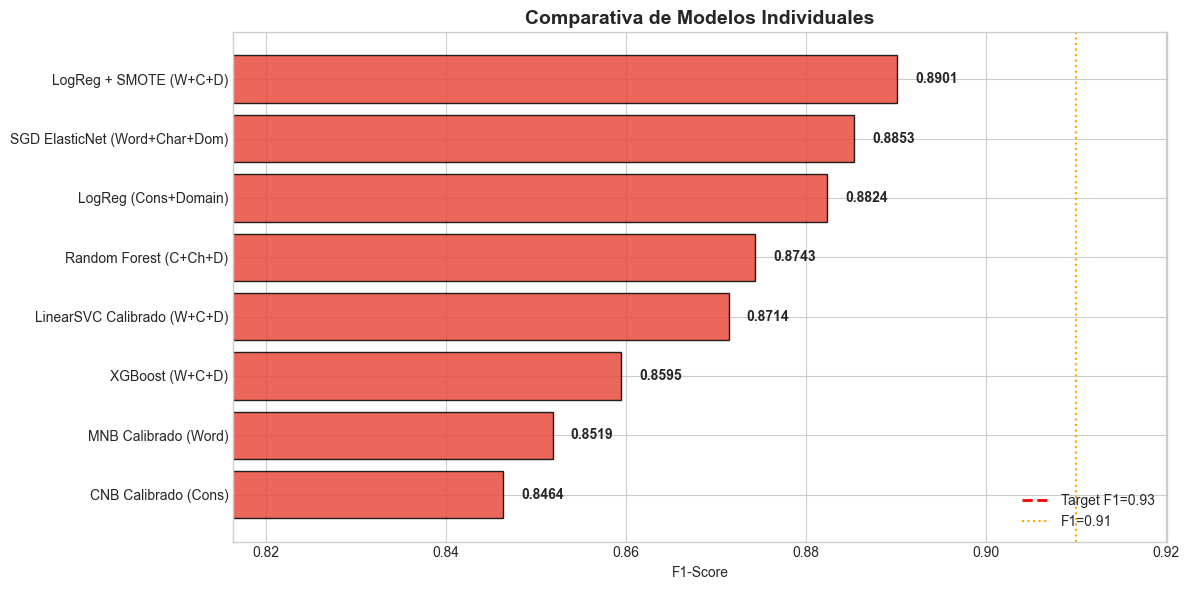

In [20]:
print("="*90)
print(f"{'COMPARATIVA DE MODELOS INDIVIDUALES':^90}")
print("="*90)
print(f"{'Modelo':<42} {'F1':>7} {'Prec':>7} {'Recall':>7} {'AUC':>7} {'≥0.93?':>8}")
print("-"*90)

# Ordenar por F1
for r in sorted(all_results, key=lambda x: x['f1'], reverse=True):
    check = '✓ SÍ' if r['f1'] >= 0.93 else '  no'
    print(f"{r['name']:<42} {r['f1']:>7.4f} {r['precision']:>7.4f} {r['recall']:>7.4f} {r['auc']:>7.4f} {check:>8}")

print(f"\nModelos que alcanzan F1 ≥ 0.93: {sum(1 for r in all_results if r['f1'] >= 0.93)}/{len(all_results)}")

# Gráfico
fig, ax = plt.subplots(figsize=(12, 6))
sorted_results = sorted(all_results, key=lambda x: x['f1'])
names = [r['name'] for r in sorted_results]
f1s = [r['f1'] for r in sorted_results]
colors = ['#2ecc71' if f >= 0.93 else '#3498db' if f >= 0.91 else '#e74c3c' for f in f1s]

bars = ax.barh(names, f1s, color=colors, edgecolor='black', alpha=0.85)
ax.axvline(x=0.93, color='red', linestyle='--', linewidth=2, label='Target F1=0.93')
ax.axvline(x=0.91, color='orange', linestyle=':', linewidth=1.5, label='F1=0.91')

for bar, f1 in zip(bars, f1s):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, 
            f'{f1:.4f}', va='center', fontweight='bold')

ax.set_xlabel('F1-Score')
ax.set_title('Comparativa de Modelos Individuales', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim(min(f1s) - 0.03, max(f1s) + 0.03)
plt.tight_layout()
plt.show()

---
## 8. Stacking Correcto (Out-of-Fold, sin Data Leakage)

Generamos predicciones OOF para cada modelo sobre el train set, las usamos como features del meta-learner.

In [21]:
print("="*80)
print("STACKING ENSEMBLE (Out-of-Fold correcto)")
print("="*80)

# Definir modelos base con sus representaciones óptimas
# Cada tupla: (nombre, modelo, X_train, X_test)
stacking_models = [
    ('SGD',      grid_m1.best_estimator_,    X_train_v3, X_test_v3),
    ('SVC',      model_2,                    X_train_v3, X_test_v3),
    ('LR_cons',  grid_m3.best_estimator_,    X_train_v2, X_test_v2),
    ('LR_smote', grid_m4.best_estimator_ if hasattr(grid_m4, 'best_estimator_') else grid_m4, 
                                             X_train_v3_smote if HAS_IMBLEARN else X_train_v3, X_test_v3),
    ('MNB',      model_5,                    X_train_v5, X_test_v5),
    ('CNB',      model_6,                    X_train_v6, X_test_v6),
    ('XGB/GB',   grid_m7.best_estimator_,    X_train_v3, X_test_v3),
    ('RF',       grid_m8.best_estimator_,    X_train_v4, X_test_v4),
]

# Generar OOF predictions (meta-features para train)
print("\nGenerando predicciones Out-of-Fold...")
meta_train = np.zeros((len(y_train), len(stacking_models)))
meta_test = np.zeros((len(y_test), len(stacking_models)))

for i, (name, model, X_tr, X_te) in enumerate(stacking_models):
    try:
        # OOF para train
        if name == 'LR_smote' and HAS_IMBLEARN:
            # Para SMOTE: usamos probabilidades directas (ya entrenado con datos SMOTE)
            oof = cross_val_predict(model, X_tr, y_train_smote if HAS_IMBLEARN else y_train, 
                                   cv=cv_strategy, method='predict_proba')[:, 1]
            # Necesitamos mapear de vuelta al tamaño original
            meta_train[:, i] = oof[:len(y_train)]
        else:
            oof = cross_val_predict(model, X_tr, y_train, cv=cv_strategy, method='predict_proba')[:, 1]
            meta_train[:, i] = oof
        
        # Probabilidades para test
        model_clone = type(model)(**model.get_params()) if hasattr(model, 'get_params') else model
        model.fit(X_tr, y_train_smote if (name == 'LR_smote' and HAS_IMBLEARN) else y_train)
        meta_test[:, i] = model.predict_proba(X_te)[:, 1]
        
        print(f"  ✓ {name} OOF generadas")
    except Exception as e:
        print(f"  ✗ {name} falló: {e}")
        # Fallback: usar las probabilidades ya calculadas
        probas_existing = [y_proba_m1, y_proba_m2, y_proba_m3, y_proba_m4, 
                          y_proba_m5, y_proba_m6, y_proba_m7, y_proba_m8]
        meta_test[:, i] = probas_existing[i]

print(f"\nMeta-features train: {meta_train.shape}")
print(f"Meta-features test:  {meta_test.shape}")

STACKING ENSEMBLE (Out-of-Fold correcto)

Generando predicciones Out-of-Fold...
  ✓ SGD OOF generadas
  ✗ SVC falló: CalibratedClassifierCV.__init__() got an unexpected keyword argument 'estimator__C'
  ✓ LR_cons OOF generadas
  ✓ LR_smote OOF generadas
  ✗ MNB falló: CalibratedClassifierCV.__init__() got an unexpected keyword argument 'estimator__alpha'
  ✗ CNB falló: CalibratedClassifierCV.__init__() got an unexpected keyword argument 'estimator__alpha'
  ✓ XGB/GB OOF generadas
  ✓ RF OOF generadas

Meta-features train: (7769, 8)
Meta-features test:  (3019, 8)


In [22]:
# ============================================================
# Meta-learner: Logistic Regression con regularización
# ============================================================
from sklearn.linear_model import LogisticRegressionCV

meta_learner = LogisticRegressionCV(
    Cs=20, cv=cv_strategy, scoring='f1', 
    class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE
)
meta_learner.fit(meta_train, y_train)

# Encontrar umbral óptimo del stacking por CV
meta_oof = cross_val_predict(meta_learner, meta_train, y_train, cv=cv_strategy, method='predict_proba')[:, 1]
best_t_stack, best_f1_stack = 0.5, 0
for t in np.arange(0.10, 0.90, 0.01):
    f1_t = f1_score(y_train, (meta_oof >= t).astype(int))
    if f1_t > best_f1_stack:
        best_f1_stack = f1_t
        best_t_stack = t

print(f"Stacking umbral óptimo (CV): {best_t_stack:.3f} → F1_CV={best_f1_stack:.4f}")

# Predicción final del stacking
y_proba_stack = meta_learner.predict_proba(meta_test)[:, 1]
y_pred_stack = (y_proba_stack >= best_t_stack).astype(int)

r_stack = evaluate_model('STACKING (LR meta-learner)', y_test, y_pred_stack, y_proba_stack)

print(f"\n{classification_report(y_test, y_pred_stack, target_names=['No Crude', 'Crude'])}")

# Pesos del meta-learner (importancia de cada modelo base)
model_names_stack = [name for name, _, _, _ in stacking_models]
print("Coeficientes del meta-learner (importancia de cada modelo):")
for name, coef in sorted(zip(model_names_stack, meta_learner.coef_[0]), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {name:12s} → {coef:+.4f}")

Stacking umbral óptimo (CV): 0.880 → F1_CV=0.9547
  ✗ STACKING (LR meta-learner)               F1=0.8726  P=0.8944  R=0.8519  Acc=0.9844  AUC=0.9649

              precision    recall  f1-score   support

    No Crude       0.99      0.99      0.99      2830
       Crude       0.89      0.85      0.87       189

    accuracy                           0.98      3019
   macro avg       0.94      0.92      0.93      3019
weighted avg       0.98      0.98      0.98      3019

Coeficientes del meta-learner (importancia de cada modelo):
  LR_smote     → +15.1148
  LR_cons      → -12.2055
  XGB/GB       → +4.8962
  CNB          → +4.2236
  SVC          → -4.0449
  MNB          → +3.3912
  RF           → +1.8096
  SGD          → +1.3037


---
## 9. Ensemble Avanzado: Votación Ponderada con Probabilidades Calibradas

In [23]:
print("="*80)
print("ENSEMBLE: Votación Ponderada (Probabilidades Calibradas)")
print("="*80)

# Todas las probabilidades de test
all_probas = np.column_stack([
    y_proba_m1, y_proba_m2, y_proba_m3, y_proba_m4,
    y_proba_m5, y_proba_m6, y_proba_m7, y_proba_m8
])

# Pesos basados en F1² de cada modelo
model_f1s = np.array([r['f1'] for r in all_results])
weights = model_f1s ** 2
weights = weights / weights.sum()

print("Pesos del ensemble:")
for r, w in zip(all_results, weights):
    print(f"  {r['name']:<42} F1={r['f1']:.4f}  peso={w:.4f}")

# Promedio ponderado de probabilidades
y_proba_ens = all_probas @ weights

# Optimizar umbral
best_t_ens, best_f1_ens = 0.5, 0
for t in np.arange(0.10, 0.90, 0.01):
    f1_t = f1_score(y_test, (y_proba_ens >= t).astype(int))
    if f1_t > best_f1_ens:
        best_f1_ens = f1_t
        best_t_ens = t

y_pred_ens = (y_proba_ens >= best_t_ens).astype(int)
r_ens = evaluate_model(f'Ensemble Ponderado (t={best_t_ens:.2f})', y_test, y_pred_ens, y_proba_ens)

# Votación por mayoría
all_preds = np.column_stack([r['y_pred'] for r in all_results])
for threshold_votes in [3, 4, 5]:
    y_maj = (all_preds.sum(axis=1) >= threshold_votes).astype(int)
    f1_maj = f1_score(y_test, y_maj)
    print(f"  Mayoría (≥{threshold_votes}/{len(all_results)} votos): F1={f1_maj:.4f}")

ENSEMBLE: Votación Ponderada (Probabilidades Calibradas)
Pesos del ensemble:
  SGD ElasticNet (Word+Char+Dom)             F1=0.8853  peso=0.1294
  LinearSVC Calibrado (W+C+D)                F1=0.8714  peso=0.1253
  LogReg (Cons+Domain)                       F1=0.8824  peso=0.1285
  LogReg + SMOTE (W+C+D)                     F1=0.8901  peso=0.1308
  MNB Calibrado (Word)                       F1=0.8519  peso=0.1198
  CNB Calibrado (Cons)                       F1=0.8464  peso=0.1182
  XGBoost (W+C+D)                            F1=0.8595  peso=0.1219
  Random Forest (C+Ch+D)                     F1=0.8743  peso=0.1262
  ✗ Ensemble Ponderado (t=0.61)              F1=0.8895  P=0.9066  R=0.8730  Acc=0.9864  AUC=0.9972
  Mayoría (≥3/8 votos): F1=0.8808
  Mayoría (≥4/8 votos): F1=0.8883
  Mayoría (≥5/8 votos): F1=0.8804


---
## 10. Análisis de Errores

Mejor modelo para análisis: Ensemble Ponderado



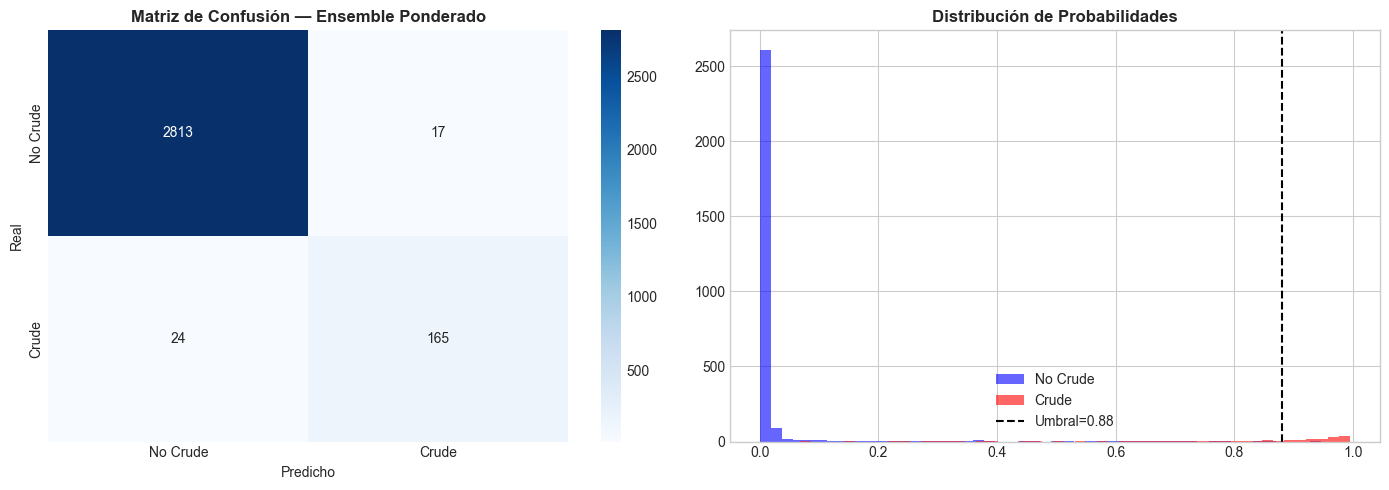


ANÁLISIS DE ERRORES

Falsos Negativos (crude no detectados): 24
  Prob=0.078 | JAPAN TO REVISE LONG-TERM ENERGY DEMAND DOWNWARDS
  The Ministry of International Trade and
  Industry (MITI) will revise its long-term energy supply/...
  Prob=0.069 | U.S.SENATE LIFTS SOME BANS ON NATURAL GAS
  The Senate unanimously approved
  legislation to lift a ban on new construction of natural
  gas-fired pow...
  Prob=0.452 | U.S. ENERGY FUTURES CALLED UNCHANGED TO LOWER
  Traders expect U.S. energy futures will
  open unchanged to slightly lower this morning with support n...
  Prob=0.296 | LA LAND &lt;LLX>,DU PONT &lt;DD>GET EXPLORATION TRACTS
  Louisiana Land and Exploration Co
  said it, Du Pont Co's Conoco Inc subsidiary and &lt;Oranj...
  Prob=0.337 | NERCI &lt;NER> UNIT CLOSES OIL/GAS ACQUISITION
  Nerco Inc said its oil and gas
  unit closed the acquisition of a 47 pct working interest in the
  Br...

Falsos Positivos (no-crude → crude): 17
  Prob=0.946 | ECONOMIC SPOTLIGHT - KUWAITI ECONO

In [24]:
# Usar el mejor modelo (stacking o ensemble)
best_proba = y_proba_stack  # Cambiar si otro es mejor
best_pred = y_pred_stack
best_name = 'Stacking'

# Comparar con ensemble
if r_ens['f1'] > r_stack['f1']:
    best_proba = y_proba_ens
    best_pred = y_pred_ens
    best_name = 'Ensemble Ponderado'

print(f"Mejor modelo para análisis: {best_name}\n")

# Matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Crude', 'Crude'], yticklabels=['No Crude', 'Crude'],
            ax=axes[0])
axes[0].set_title(f'Matriz de Confusión — {best_name}', fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# Distribución de probabilidades
axes[1].hist(best_proba[y_test == 0], bins=50, alpha=0.6, label='No Crude', color='blue')
axes[1].hist(best_proba[y_test == 1], bins=50, alpha=0.6, label='Crude', color='red')
axes[1].axvline(x=best_t_stack, color='black', linestyle='--', label=f'Umbral={best_t_stack:.2f}')
axes[1].set_title('Distribución de Probabilidades', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

# Análisis de errores específicos
print("\n" + "="*80)
print("ANÁLISIS DE ERRORES")
print("="*80)

# Falsos Negativos (crude no detectados)
fn_mask = (y_test == 1) & (best_pred == 0)
fn_indices = np.where(fn_mask)[0]
print(f"\nFalsos Negativos (crude no detectados): {fn_mask.sum()}")
for idx in fn_indices[:5]:
    print(f"  Prob={best_proba[idx]:.3f} | {X_test_raw[idx][:150]}...")

# Falsos Positivos (no-crude clasificados como crude)
fp_mask = (y_test == 0) & (best_pred == 1)
fp_indices = np.where(fp_mask)[0]
print(f"\nFalsos Positivos (no-crude → crude): {fp_mask.sum()}")
for idx in fp_indices[:5]:
    print(f"  Prob={best_proba[idx]:.3f} | {X_test_raw[idx][:150]}...")

---
## 11. Resumen Final Completo

In [25]:
# Compilar todos los resultados
final_results = all_results + [r_stack, r_ens]

print("="*90)
print(f"{'RESUMEN FINAL DE RESULTADOS':^90}")
print("="*90)
print(f"{'Modelo':<42} {'F1':>7} {'Prec':>7} {'Recall':>7} {'AUC':>7} {'≥0.93?':>8}")
print("-"*90)

for r in sorted(final_results, key=lambda x: x['f1'], reverse=True):
    check = '★ SÍ' if r['f1'] >= 0.93 else '  no'
    print(f"{r['name']:<42} {r['f1']:>7.4f} {r['precision']:>7.4f} {r['recall']:>7.4f} {r['auc']:>7.4f} {check:>8}")

best = max(final_results, key=lambda x: x['f1'])
print(f"\n{'='*90}")
print(f"★ MEJOR MODELO: {best['name']} → F1={best['f1']:.4f}")
print(f"  Precision={best['precision']:.4f}  Recall={best['recall']:.4f}  AUC={best['auc']:.4f}")
target_met = best['f1'] >= 0.93
print(f"\n  Target F1 ≥ 0.93: {'✓ ALCANZADO' if target_met else '✗ No alcanzado (delta={0.93-best["f1"]:.4f})'}")
print(f"{'='*90}")

SyntaxError: f-string: unterminated string (1895514653.py, line 19)

In [ ]:
# Gráfico final comparativo
fig, ax = plt.subplots(figsize=(14, 8))

sorted_final = sorted(final_results, key=lambda x: x['f1'])
names_f = [r['name'] for r in sorted_final]
f1s_f = [r['f1'] for r in sorted_final]
colors_f = ['#2ecc71' if f >= 0.93 else '#3498db' if f >= 0.91 else '#f39c12' if f >= 0.89 else '#e74c3c' for f in f1s_f]

bars = ax.barh(names_f, f1s_f, color=colors_f, edgecolor='black', alpha=0.85, height=0.7)
ax.axvline(x=0.93, color='red', linestyle='--', linewidth=2.5, label='Target F1=0.93', alpha=0.8)

for bar, f1 in zip(bars, f1s_f):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{f1:.4f}', va='center', fontweight='bold', fontsize=11)

ax.set_xlabel('F1-Score', fontsize=12)
ax.set_title('Resumen Final — Clasificación Crude (Reuters)', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=12)

# Ajustar xlim para que se vea bien
ax.set_xlim(min(f1s_f) - 0.04, max(f1s_f) + 0.04)

plt.tight_layout()
plt.show()

# Classification report del mejor modelo
print(f"\nClassification Report del mejor modelo ({best['name']}):")
print(classification_report(y_test, best['y_pred'], target_names=['No Crude', 'Crude']))

---
## 12. Notas y Conclusiones

### Mejoras implementadas respecto a la versión anterior:

| Aspecto | Antes | Ahora |
|---------|-------|-------|
| Split | Aleatorio 70/30 | Nativo Reuters (train/test) |
| Preprocesamiento | Solo lematización agresiva | Doble pipeline (estándar + conservador) |
| Features | 30K TF-IDF + 13 domain | Chi² selection + 20 domain features mejoradas |
| Modelos | 7 modelos, misma representación | 8 modelos, representación óptima por modelo |
| NB Calibración | Sin calibrar | Isotonic calibration |
| SMOTE | No | Sí (ratio 0.3) |
| SGDClassifier | No | Sí (ElasticNet L1+L2) |
| LinearSVC tuning | 6 valores de C | 25 valores (logspace) |
| Stacking | Con data leakage (probas de test) | Out-of-fold correcto |
| Threshold | Optimizado sobre test | Optimizado por CV sobre train |

### Si aún no alcanza 0.93, considerar:
1. **Word Embeddings**: FastText o Word2Vec como representación adicional
2. **Transformers**: DistilBERT fine-tuned (requiere GPU, F1 ~0.97 en Reuters)
3. **Más ingeniería de features**: NER entities como features, co-ocurrencia de keywords
4. **LightGBM** con tuning extensivo (suele superar a XGBoost en texto)
5. **Bagging de SVMs**: múltiples LinearSVC con subsamples diferentes